In [1]:
import os
os.environ["GDAL_PAM_ENABLED"] = 'NO'
import numpy as np
from glob import glob
from spectral.io import envi
import matplotlib.pyplot as plt

import rasterio
from rasterio.warp import reproject, Resampling

import sys
sys.path.append('/store/carroll/repos/neon-isofit')
from utilities import *

%matplotlib widget

In [2]:
home = '/store/carroll/col/data/2018/'

In [12]:
flights = [x.split('/')[-1].replace('_rdn_ort_igm_ort','') for x in glob(os.path.join(home, 'raw/rmbl', '*', '*rdn_ort_igm_ort'))]
flights

['NIS01_20180612_154959',
 'NIS01_20180612_155442',
 'NIS01_20180612_155857',
 'NIS01_20180612_160340',
 'NIS01_20180612_160819',
 'NIS01_20180612_161352',
 'NIS01_20180612_161935',
 'NIS01_20180612_162711',
 'NIS01_20180612_163536',
 'NIS01_20180612_164336',
 'NIS01_20180612_165127',
 'NIS01_20180612_165936',
 'NIS01_20180612_170742',
 'NIS01_20180612_171559',
 'NIS01_20180612_172418',
 'NIS01_20180612_173258',
 'NIS01_20180612_174155',
 'NIS01_20180612_175319',
 'NIS01_20180613_153952',
 'NIS01_20180613_154908',
 'NIS01_20180613_155851',
 'NIS01_20180613_160919',
 'NIS01_20180613_161901',
 'NIS01_20180613_162848',
 'NIS01_20180613_163918',
 'NIS01_20180613_164943',
 'NIS01_20180613_170023',
 'NIS01_20180613_171044',
 'NIS01_20180613_172129',
 'NIS01_20180613_173216',
 'NIS01_20180613_174241',
 'NIS01_20180613_175553',
 'NIS01_20180619_153052',
 'NIS01_20180619_154149',
 'NIS01_20180619_155226',
 'NIS01_20180619_160339',
 'NIS01_20180619_161406',
 'NIS01_20180619_162542',
 'NIS01_2018

In [3]:
# test func

flight = 'NIS01_20180612_155442'
fp_ref = glob(os.path.join(home, 'raw/rmbl', '*', f'{flight}_rdn_ort_igm_ort'))[0]
fp_skyview = os.path.join(home, 'skyview', 'sky_view_factor_10m')
fp_out = os.path.join(home, 'skyview', 'skyview10_flightlines', f'skyview10_{flight}')

clip_skyview_per_flightline(fp_skyview, fp_ref, fp_out)

(3809, 1311) (3809, 1311)


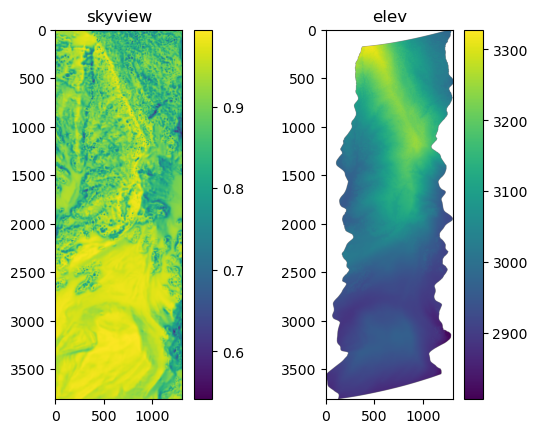

In [5]:
# compare

skyview_flight = envi.open(fp_out+'.hdr').open_memmap()[...,0]
ref = envi.open(fp_ref+'.hdr').open_memmap()[...,2].copy()
ref[ref==-9999] = np.nan

print(skyview_flight.shape, ref.shape)

fig, axs = plt.subplots(ncols=2)

p0 = axs[0].imshow(skyview_flight)
axs[0].set_title('skyview')

p1 = axs[1].imshow(ref)
axs[1].set_title('elev')

fig.colorbar(p0, ax=axs[0], orientation="vertical")
fig.colorbar(p1, ax=axs[1], orientation="vertical")

plt.show()

In [24]:
# # clip dsm per flightline (buffered by 1.5 km)

# flight = 'NIS01_20180612_155442'

# fp = glob(os.path.join(home, 'raw/rmbl', '*', f'{flight}_rdn_ort'))[0]

# fp_out = os.path.join(home, 'skyview', f'{flight}_dsm_buf')

# # buffer flightline by 1.5km
# with rasterio.open(fp) as ref:
#     ref_bounds = ref.bounds
#     ref_poly = box(ref_bounds.left, ref_bounds.bottom, ref_bounds.right, ref_bounds.top)
#     ref_poly_buf = ref_poly.buffer(1500)

# # clip dsm by buffered poly
# with rasterio.open(fp_dsm) as src:
#     win = from_bounds(*ref_poly_buf.bounds, transform=src.transform).round_offsets().round_shape() # build a window from bounds, round offsets and shape as necessary
#     out_transform = window_transform(win, src.transform)
#     data = src.read(window=win) # load data in that window

#     out_profile = src.profile.copy()
#     out_profile.update({
#         'driver': 'ENVI',
#         'height': win.height,
#         'width': win.width,
#         'transform': out_transform
#     })

# # export
# with rasterio.open(fp_out, 'w', **out_profile) as dst:
#     dst.write(data)

# # now I want to run the above through skyview

# # skyview = np.ones(data.shape)
# # skyview.shape

# # and then clip that skyview raster to 

# # with rasterio.open(fp) as ref:
# #     ref_profile = ref.profile
# #     ref_transform = ref.transform
# #     ref_crs = ref.crs
# #     ref_shape = (ref.height, ref.width)

# # with rasterio.open(fp_dsm) as src:
# #     out_array = np.empty(ref_shape, dtype=src.dtypes[0])
# #     reproject(
# #         source=rasterio.band(src, 1),
# #         destination=out_array,
# #         src_transform=src.transform,
# #         src_crs=src.crs,
# #         dst_transform=ref_transform,
# #         dst_crs=ref_crs,
# #         resampling=Resampling.nearest  # or bilinear/cubic for continuous data
# #     )

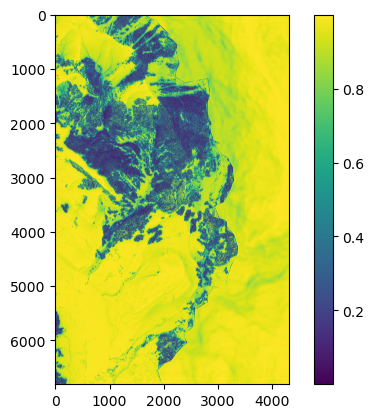

In [26]:
# # NIS01_20180612_155442_skyview

# # hmm the 1m resolution makes the forest canoopy have pretty low skyview... is that accurate?
# fp = '/store/carroll/col/data/2018/skyview/sky_view_factor.hdr'
# tmp = envi.open(fp).open_memmap()

# fig = plt.figure()
# plt.imshow(tmp[...,0])
# plt.colorbar()
# plt.show()

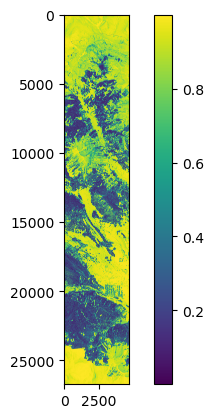

In [27]:
# # NIS01_20180616_162542_skyview
# # hmm the 1m resolution makes the forest canoopy have pretty low skyview... is that accurate?
# fp = '/store/carroll/col/data/2018/skyview/sky_view_factor.hdr'
# tmp = envi.open(fp).open_memmap()

# fig = plt.figure()
# plt.imshow(tmp[...,0])
# plt.colorbar()
# plt.show()

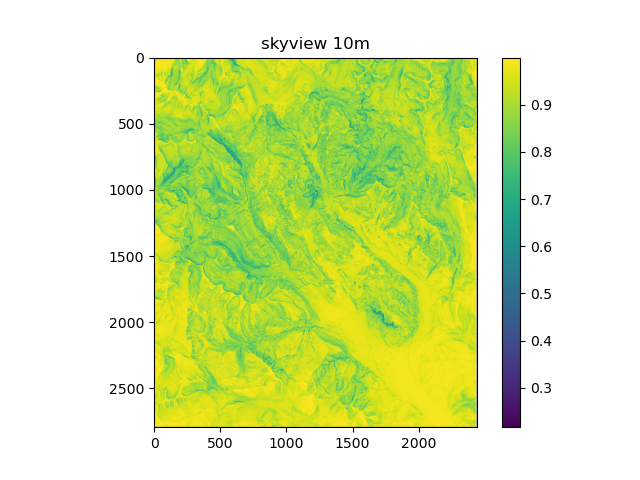

In [3]:
# whole 10m skyview

fp = '/store/carroll/col/data/2018/skyview/sky_view_factor_10m.hdr'
tmp = envi.open(fp).open_memmap()

fig = plt.figure()
plt.imshow(tmp[...,0])
plt.title('skyview 10m')
plt.colorbar()
plt.show()